In [1]:
    # h_daily, c_daily = torch.sum(h_daily, axis=0), torch.sum(c_daily, axis=0)
        
    #     att_weights = torch.unsqueeze(torch.nn.functional.softmax(self.att_daily(x_encoder).squeeze(), dim=1), dim=-1)
    #     h_daily_att = att_weights*x_encoder
    #     h_daily_att = torch.sum(h_daily_att, dim=1)

In [15]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import optim
from torch.utils.data import Subset
from model import DayCentModel
from data import DayCentDataset
import os
import wandb
from utils import evaluate

In [2]:
# Reproducibility
RND_SEED = 42
np.random.seed(RND_SEED)
torch.manual_seed(RND_SEED)

In [3]:
INPUT_NPY = "/users/6/mehta423/daycent/data/experiment2/train_X.npy"
OUTPUT_NPY = "/users/6/mehta423/daycent/data/experiment2/train_Y.npy"
INIT_COND = "/users/6/mehta423/daycent/data/SAS_KGML_090925/InputData/initial_site_conditions.xlsx"
OUTPUT_DIR = "/users/6/mehta423/daycent/output/experiment2"

In [6]:
# ----------------------
# Config
# ----------------------
BATCH_SIZE = 2048
EPOCHS = 100
LR = 1e-2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    # Set the wandb project where this run will be logged.
    project="daycent",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": LR,
        "architecture": "LSTM with Attention",
        "dataset": "10 Scenarios, 100 Points",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE
    },
)

In [7]:
# ----------------------
# Dataloader
# ----------------------
# check dataset
dataset = DayCentDataset(INPUT_NPY, OUTPUT_NPY, INIT_COND, apply_scaling=True)

0


In [8]:
len(dataset)

25000

In [9]:
# 1) Define split boundaries
train_size = 2500 * 7
val_size = 2500 * 2    
test_size = 2500       
# Total: 25000

# 2) Create index arrays for each split
train_idx = np.arange(0, train_size)
val_idx = np.arange(train_size, train_size + val_size)
test_idx = np.arange(train_size + val_size, train_size + val_size + test_size)

# 3) Wrap subsets
train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)
test_ds  = Subset(dataset, test_idx)

# 4) Create loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Dataset sizes — total: {len(dataset)}, train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Dataset sizes — total: 25000, train: 17500, val: 5000, test: 2500


In [10]:
# infer input dim
sample = dataset[0]
seq_feat_dim = sample["sequence"].shape[1]  # #features
init_dim = sample["init_cond"].shape[0]
year_dim = sample["year_enc"].shape[0]

print(f"Input feature dim: {seq_feat_dim}, init cond dim: {init_dim}, year enc dim: {year_dim}")

Input feature dim: 20, init cond dim: 245, year enc dim: 16


In [11]:

model = DayCentModel(input_dim=seq_feat_dim, init_dim=init_dim, year_dim=year_dim)
model.to(DEVICE)

DayCentModel(
  (init_proj): Linear(in_features=261, out_features=32, bias=True)
  (daily_proj): Linear(in_features=20, out_features=32, bias=True)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True)
  (somsc_attn): AttentionPooling(
    (attn): Linear(in_features=128, out_features=1, bias=True)
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (yield_attn): AttentionPooling(
    (attn): Linear(in_features=128, out_features=1, bias=True)
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (somsc_head): Linear(in_features=128, out_features=1, bias=True)
  (yield_head): Linear(in_features=128, out_features=1, bias=True)
)

In [12]:
# ----------------------
# Optimizer & scheduler
# ----------------------
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

Epoch 1/100 - Loss: 1.0116
  Val SOMSC Loss: 0.7761, Yield Loss: 1.0521
Saved best model at epoch 0 with val_loss: 1.0521
Epoch 2/100 - Loss: 0.6038
  Val SOMSC Loss: 0.4389, Yield Loss: 1.0554
Epoch 3/100 - Loss: 0.5835
  Val SOMSC Loss: 0.4323, Yield Loss: 1.0080
Saved best model at epoch 2 with val_loss: 1.0080
Epoch 4/100 - Loss: 0.6035
  Val SOMSC Loss: 0.3821, Yield Loss: 0.9843
Saved best model at epoch 3 with val_loss: 0.9843
Epoch 5/100 - Loss: 0.5705
  Val SOMSC Loss: 0.3996, Yield Loss: 1.0453
Epoch 6/100 - Loss: 0.5502
  Val SOMSC Loss: 0.1962, Yield Loss: 0.9217
Saved best model at epoch 5 with val_loss: 0.9217
Epoch 7/100 - Loss: 0.5147
  Val SOMSC Loss: 0.1148, Yield Loss: 0.9317
Epoch 8/100 - Loss: 0.5151
  Val SOMSC Loss: 0.1203, Yield Loss: 0.9055
Saved best model at epoch 7 with val_loss: 0.9055
Epoch 9/100 - Loss: 0.5065
  Val SOMSC Loss: 0.1158, Yield Loss: 0.8743
Saved best model at epoch 8 with val_loss: 0.8743
Epoch 10/100 - Loss: 0.4964
  Val SOMSC Loss: 0.0939

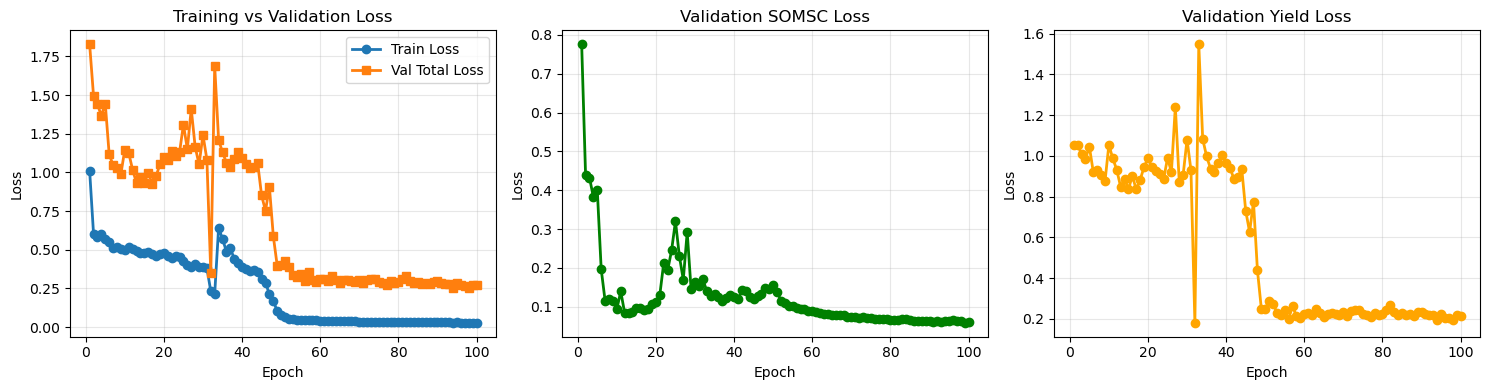


Final Results:
Best Validation Total Loss: 0.2541 at epoch 98
Best Validation SOMSC Loss: 0.0583 at epoch 99
Best Validation Yield Loss: 0.1805 at epoch 32


In [16]:
import matplotlib.pyplot as plt

# ----------------------
# Training loop with loss tracking
# ----------------------
best_val_loss = float('inf')


# Initialize loss tracking lists
train_losses = []
val_somsc_losses = []
val_yield_losses = []
val_total_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        # move to device
        batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        optimizer.zero_grad()
        out = model(batch)

        # --- SOMSC loss ---
        somsc_target = batch["somsc"]              # (B,12)
        somsc_mask = batch["somsc_mask"]           # (B,12)

        # compute masked MSE
        somsc_loss = ((out["somsc_pred"].squeeze(-1) - somsc_target)**2 * somsc_mask).sum() / somsc_mask.sum()

        # --- Yield loss ---
        yield_target = batch["yield"]              # (B,)
        yield_mask = batch["yield_mask"]           # (B,)
        yield_loss = ((out["yield_pred"] - yield_target)**2 * yield_mask).sum() / yield_mask.sum()

        # --- total loss ---
        alpha = 1.0  # weight for SOMSC loss
        beta = 1.0   # weight for Yield loss
        loss = alpha*somsc_loss + beta*yield_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch["sequence"].size(0)

    total_loss /= len(dataset)
    train_losses.append(total_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")
    somsc_loss_val, yield_loss_val = evaluate(model, val_loader, DEVICE)
    print(f"  Val SOMSC Loss: {somsc_loss_val:.4f}, Yield Loss: {yield_loss_val:.4f}")

    if yield_loss_val < best_val_loss:
        best_val_loss = yield_loss_val
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pth"))
        print(f"Saved best model at epoch {epoch} with val_loss: {yield_loss_val:.4f}")
    
    # Track validation losses
    val_somsc_losses.append(somsc_loss_val)
    val_yield_losses.append(yield_loss_val)
    val_total_losses.append(somsc_loss_val + yield_loss_val)

    run.log({
        "epoch": epoch + 1,
        "train_loss": total_loss,
        "val_somsc_loss": somsc_loss_val,
        "val_yield_loss": yield_loss_val,
        "val_total_loss": somsc_loss_val + yield_loss_val,
        "learning_rate": optimizer.param_groups[0]['lr'],
    })

    scheduler.step(total_loss)


# ----------------------
# Plot losses
# ----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Training vs Total Validation Loss
axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss', linewidth=2)
axes[0].plot(range(1, EPOCHS+1), val_total_losses, marker='s', label='Val Total Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation SOMSC Loss
axes[1].plot(range(1, EPOCHS+1), val_somsc_losses, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation SOMSC Loss')
axes[1].grid(True, alpha=0.3)

# Plot 3: Validation Yield Loss
axes[2].plot(range(1, EPOCHS+1), val_yield_losses, marker='o', color='orange', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Validation Yield Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal Results:")
print(f"Best Validation Total Loss: {min(val_total_losses):.4f} at epoch {val_total_losses.index(min(val_total_losses))+1}")
print(f"Best Validation SOMSC Loss: {min(val_somsc_losses):.4f} at epoch {val_somsc_losses.index(min(val_somsc_losses))+1}")
print(f"Best Validation Yield Loss: {min(val_yield_losses):.4f} at epoch {val_yield_losses.index(min(val_yield_losses))+1}")

In [17]:
evaluate(model, test_loader, DEVICE)

(0.11380895118713379, 0.14533172607421874)

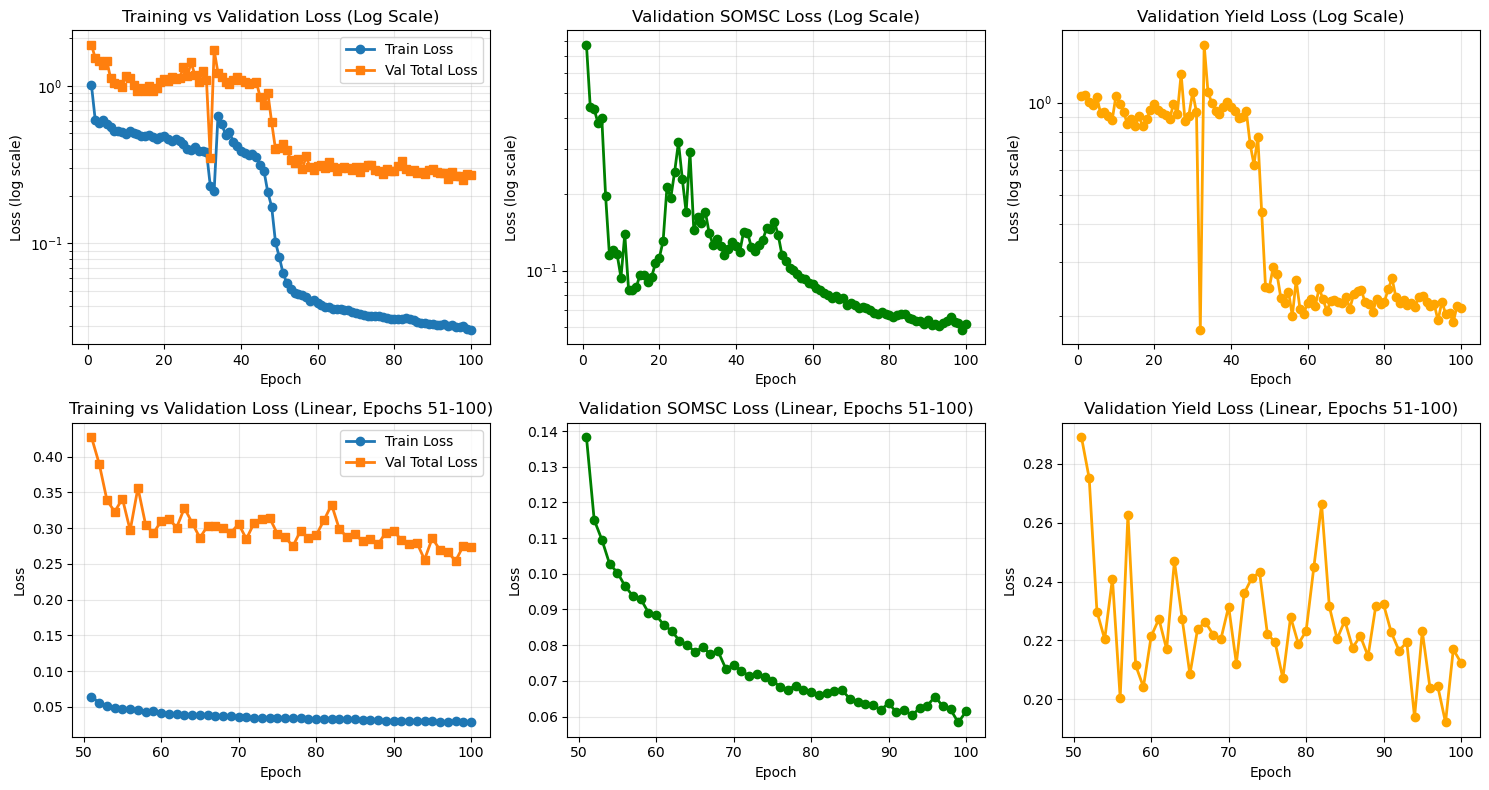

In [ ]:
# ----------------------
# Plot losses - Split view
# ----------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: Log scale (full training)
axes[0, 0].plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss', linewidth=2)
axes[0, 0].plot(range(1, EPOCHS+1), val_total_losses, marker='s', label='Val Total Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log scale)')
axes[0, 0].set_title('Training vs Validation Loss (Log Scale)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, which='both')

axes[0, 1].plot(range(1, EPOCHS+1), val_somsc_losses, marker='o', color='green', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss (log scale)')
axes[0, 1].set_title('Validation SOMSC Loss (Log Scale)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3, which='both')

axes[0, 2].plot(range(1, EPOCHS+1), val_yield_losses, marker='o', color='orange', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss (log scale)')
axes[0, 2].set_title('Validation Yield Loss (Log Scale)')
axes[0, 2].set_yscale('log')
axes[0, 2].grid(True, alpha=0.3, which='both')

# Row 2: Linear scale (last 50% of epochs for detail)
start_epoch = EPOCHS // 2
axes[1, 0].plot(range(start_epoch+1, EPOCHS+1), train_losses[start_epoch:], marker='o', label='Train Loss', linewidth=2)
axes[1, 0].plot(range(start_epoch+1, EPOCHS+1), val_total_losses[start_epoch:], marker='s', label='Val Total Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title(f'Training vs Validation Loss (Linear, Epochs {start_epoch+1}-{EPOCHS})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(start_epoch+1, EPOCHS+1), val_somsc_losses[start_epoch:], marker='o', color='green', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title(f'Validation SOMSC Loss (Linear, Epochs {start_epoch+1}-{EPOCHS})')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(range(start_epoch+1, EPOCHS+1), val_yield_losses[start_epoch:], marker='o', color='orange', linewidth=2)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Loss')
axes[1, 2].set_title(f'Validation Yield Loss (Linear, Epochs {start_epoch+1}-{EPOCHS})')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

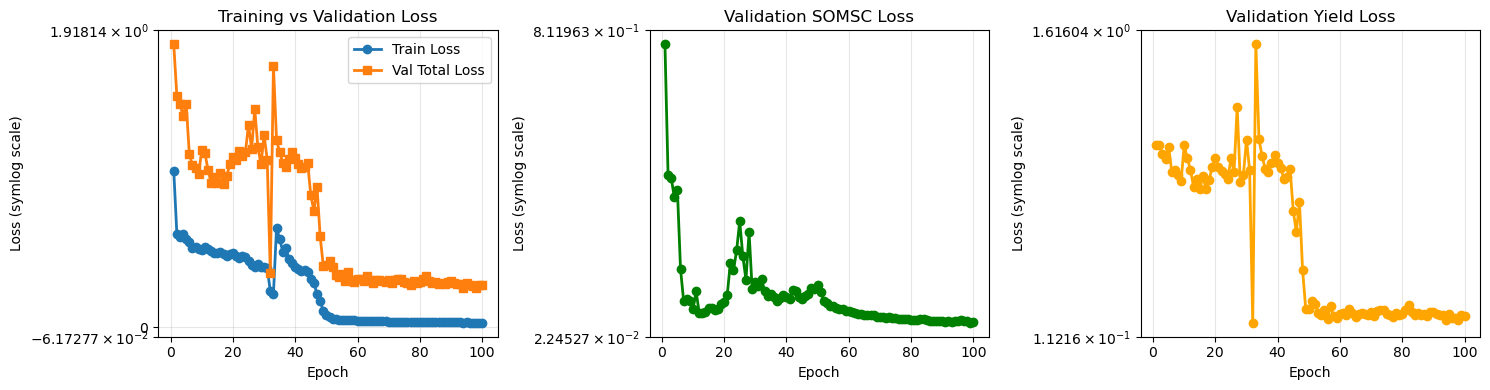

In [19]:
# ----------------------
# Plot losses (symlog scale)
# ----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss', linewidth=2)
axes[0].plot(range(1, EPOCHS+1), val_total_losses, marker='s', label='Val Total Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (symlog scale)')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_yscale('symlog', linthresh=1e4)  # adjust linthresh based on your data
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), val_somsc_losses, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (symlog scale)')
axes[1].set_title('Validation SOMSC Loss')
axes[1].set_yscale('symlog', linthresh=1e3)
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, EPOCHS+1), val_yield_losses, marker='o', color='orange', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (symlog scale)')
axes[2].set_title('Validation Yield Loss')
axes[2].set_yscale('symlog', linthresh=1e3)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
run.finish()


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
learning_rate,███████████████▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▄▄▄▄▄▄▄▂▅▄▃▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_somsc_loss,█▂▂▂▃▁▂▂▂▄▆▃▆▃▃▂▃▂▂▂▂▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_total_loss,▇▇▅▅▅▄▄▅▅▅▆▆▁█▅▅▅▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_yield_loss,▆▆▆▆▆▅▅▆▆▆▆▆▆█▆▇▇▆▆▆▆▅▃▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
learning_rate,0.0025
train_loss,0.02827
val_somsc_loss,0.06142
val_total_loss,0.27383
